<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-rl-world-model-02-dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gymnasium - Gameplay Frame Latent Compression with Autoencoder - Part 2 - Train Dynamics Model

In [1]:
# TODO: load processed dataset

In [2]:
!pip install wandb datasets tsilva_notebook_utils==0.0.57

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and

In [3]:
import os
from tsilva_notebook_utils.colab import notebook_id_from_title

def setup_config():
    # @markdown ### 🏋️ Notebook Settings

    # @markdown Random nb_seed used for reproducibility across runs
    nb_seed = 42  # @param {type: "integer"}

    # @markdown ### 🗂️ Dataset Settings

    # @markdown Dataset ID to load gameplay recordings from
    ds_id = "tsilva/GymnasiumRecording__Tetris_GameBoy"  # @param {type: "string"}

    # @markdown ### 🏋️️ Training Image Augmentation Settings

    # @markdown Compile model
    model_compile = True  # @param {type: "boolean"}
    # @markdown Dimensionality of the learned latent space
    model_latent_dim = 32  # @param {type: "integer"}
    # @markdown Noise added to the latent representation
    model_latent_noise_factor = 0.0  # @param {type: "number"}
    # @markdown Small constant for latent computations
    model_latent_sparsity_epsilon = 1e-3  # @param {type: "number"}

    # @markdown ### 🏋️ Training Settings

    # @markdown Total number of training epochs
    train_n_epochs = 100  # @param {type: "integer"}
    # @markdown Number of samples per batch
    train_batch_size = 128  # @param {type: "integer"}
    # @markdown Maximum gradient norm for clipping
    train_max_grad_norm = 0  # @param {type: "number"}
    # @markdown L2 weight decay for optimizer
    train_weight_decay = 0  # @param {type: "number"}
    # @markdown Proportion of steps for learning rate warmup
    train_warmup_ratio = 0  # @param {type: "number"}
    # @markdown Loss function used
    train_loss_function = "l1"  # @param ["l1", "mse"]
    # @markdown Optimizer learning rate
    train_learning_rate = 0.001  # @param {type: "number"}
    # @markdown  train_drift amount during training on reconstructions
    train_drift = 1  # @param {type: "integer"}
    # @markdown Number of epochs between validations
    val_epochs = 10  # @param {type: "integer"}

    # Set notebook ID in the environment
    os.environ["NOTEBOOK_ID"] = notebook_id_from_title()

    return dict(
        # Notebook
        nb_seed=nb_seed,

        # Dataset
        ds_id=ds_id,

        # Model
        model_compile=model_compile,
        model_latent_dim=model_latent_dim,
        model_latent_noise_factor=model_latent_noise_factor,

        # Training
        train_n_epochs=train_n_epochs,
        train_batch_size=train_batch_size,
        train_max_grad_norm=train_max_grad_norm,
        train_weight_decay=train_weight_decay,
        train_warmup_ratio=train_warmup_ratio,
        train_loss_function=train_loss_function,
        train_learning_rate=train_learning_rate,
        train_drift=train_drift,
        val_epochs=val_epochs
    )

CONFIG = setup_config()

In [4]:
from datasets import load_dataset
raw_dataset = load_dataset(CONFIG["ds_id"], split="train")
raw_dataset

README.md:   0%|          | 0.00/389 [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 36054
})

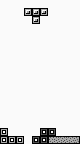

In [5]:
from tsilva_notebook_utils.datasets import process_images
from torchvision.transforms.functional import to_pil_image

PROCESS_IMAGE_CONFIG = {
    "mode" : CONFIG["ds_image_mode"],
    "quantize_colors" : CONFIG["ds_image_quantize_colors"],
    "scale" : CONFIG["ds_image_scale"],
    "crop_paddings" : [int(x) for x in CONFIG["ds_image_crop_paddings"].split(",")]
}
processed_image_t = process_images([raw_dataset[400]["image"]], **PROCESS_IMAGE_CONFIG)[0]
processed_image = to_pil_image(processed_image_t)
processed_image

In [6]:
from tsilva_notebook_utils.datasets import dedupe_dataset
deduped_dataset = dedupe_dataset(raw_dataset, "image") if CONFIG["ds_dedupe_frames"] else raw_dataset.map(lambda x:x, batched=True)
deduped_dataset

Filter:   0%|          | 0/36054 [00:00<?, ? examples/s]

Dataset({
    features: ['episode_id', 'image', 'step', 'action'],
    num_rows: 5012
})

In [7]:
def _map_process_images(batch):
    xs = process_images(batch["image"], **PROCESS_IMAGE_CONFIG)
    return dict(x=xs, y=xs)

processed_dataset = deduped_dataset.map(
    _map_process_images,
    batched=True,
    batch_size=64
)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

In [8]:
processed_dataset = processed_dataset.remove_columns(['episode_id', 'image', 'step'])

In [9]:
processed_dataset = processed_dataset.with_format("torch")

In [10]:
processed_image_t =processed_dataset[0]["x"]

In [11]:
image_channels, image_height, image_width = processed_image_t.shape
image_channels, image_height, image_width

(1, 144, 80)

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
from tsilva_notebook_utils.torch import get_current_device

class ConvAutoencoder(nn.Module):
    def __init__(self, input_channels, output_channels, input_height, input_width, model_latent_dim=None, use_bottleneck=True):
        super(ConvAutoencoder, self).__init__()

        self.model_latent_noise_factor = CONFIG['model_latent_noise_factor']
        if model_latent_dim is None:
            model_latent_dim = CONFIG['model_latent_dim']
        self.use_bottleneck = use_bottleneck

        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=4, stride=2, padding=1),  # down 2x
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # down 2x
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # down 2x
            nn.ReLU()
        )

        # Dummy forward pass to compute conv output size
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_height, input_width)
            dummy_output = self.encoder_conv(dummy_input)
            self._flattened_size = dummy_output.view(1, -1).shape[1]
            self._conv_output_shape = dummy_output.shape[1:]

        if self.use_bottleneck:
            self.fc_enc = nn.Linear(self._flattened_size, model_latent_dim)
            self.fc_dec = nn.Linear(model_latent_dim, self._flattened_size)

        # --- Decoder ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # up 2x
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # up 2x
            nn.ReLU(),

            nn.ConvTranspose2d(32, output_channels, kernel_size=4, stride=2, padding=1),  # up 2x
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        if self.use_bottleneck:
            x = x.view(x.size(0), -1)
            x = self.fc_enc(x)
        return x

    def decode(self, z):
        if self.use_bottleneck:
            z = self.fc_dec(z)
            z = z.view(z.size(0), *self._conv_output_shape)
        z = self.decoder_conv(z)
        return z

    def forward(self, x):
        z = self.encode(x)
        z_input = z

        if self.training and self.model_latent_noise_factor > 0:
            noise = torch.randn_like(z_input) * self.model_latent_noise_factor
            z_input += noise

        out = self.decode(z_input)
        return out, z

model_latent_dim = CONFIG['model_latent_dim']
use_bottleneck = model_latent_dim > 0
input_channels = image_channels
output_channels = image_channels
device = get_current_device()
representation_model = ConvAutoencoder(input_channels, output_channels, image_height, image_width, use_bottleneck=use_bottleneck).to(device)
representation_model = torch.compile(representation_model) if CONFIG["model_compile"] else representation_model
representation_model

OptimizedModule(
  (_orig_mod): ConvAutoencoder(
    (encoder_conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
    )
    (fc_enc): Linear(in_features=23040, out_features=32, bias=True)
    (fc_dec): Linear(in_features=32, out_features=23040, bias=True)
    (decoder_conv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Sigmoid()
    )
  )
)

In [13]:
from torch.utils.data import IterableDataset, DataLoader
dataloader = DataLoader(processed_dataset, batch_size=8)

for batch in dataloader:
    print(type(batch["x"][0]))
    break

<class 'torch.Tensor'>


In [14]:
from tsilva_notebook_utils.video import render_video_from_dataloader
render_video_from_dataloader(dataloader, scale=2)

In [25]:
from tsilva_notebook_utils.datasets import ShiftedDataset

from datasets import Dataset
from torch.utils.data import TensorDataset


import torch

# TODO: move to utisl
# TODO: softcode dataset so that we only specify which features to shift and all others are the same
# TODO: preserve info functionality
class ShiftedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, shift=1):
        self.base_dataset = base_dataset
        self.shift = shift
    def __len__(self):
        return len(self.base_dataset) - self.shift
    def __getitem__(self, idx):
        x = self.base_dataset[idx]["x"]
        y = self.base_dataset[idx + self.shift]["y"]
        action = self.base_dataset[idx]["action"]
        return dict(x=x, y=y, action=action)

shifted_dataset = ShiftedDataset(processed_dataset, shift=CONFIG["train_drift"])

# Pre-cache latents
with torch.no_grad():
    zs0, zs1, acts = [], [], []
    for batch in DataLoader(shifted_dataset, batch_size=512):
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        a = batch["action"].to(device)
        zs0.append(representation_model.encode(x))
        zs1.append(representation_model.encode(y))
        acts.append(a)

latent_dataset = TensorDataset(torch.cat(zs0), torch.cat(acts), torch.cat(zs1))
train_loader = DataLoader(latent_dataset, batch_size=CONFIG["train_batch_size"], shuffle=True, num_workers=4, pin_memory=True)

#render_video_from_dataloader(shifted_dataloader, scale=2)

In [21]:
from huggingface_hub import hf_hub_download

# Replace with your model repo and filename
ds_id = "tsilva/GymnasiumRecording__Tetris_GameBoy"
model_path = hf_hub_download(
    repo_id=f"{ds_id}-representation",  # e.g., "facebook/wav2vec2-base-960h"
    filename="model.pt",                # the file inside the repo
)

print(f"Model downloaded to: {model_path}")

# Now load the state dict
state_dict = torch.load(model_path)  # or "cuda" if you want to directly load onto GPU

# Load the weights into your model
representation_model.load_state_dict(state_dict)

# Set model to evaluation mode if you're going to use it for inference
representation_model.eval()
# Load it with torch if needed
#import torch
#model = torch.load(model_path)


Model downloaded to: /root/.cache/huggingface/hub/models--tsilva--GymnasiumRecording__Tetris_GameBoy-representation/snapshots/dd0cd9d7e7f897cacd14614ef2be146fa52c5336/model.pt


OptimizedModule(
  (_orig_mod): ConvAutoencoder(
    (encoder_conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
    )
    (fc_enc): Linear(in_features=23040, out_features=32, bias=True)
    (fc_dec): Linear(in_features=32, out_features=23040, bias=True)
    (decoder_conv): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): Sigmoid()
    )
  )
)

In [17]:
render_video_from_dataloader(dataloader, model=representation_model, scale=2)

/usr/local/lib/python3.11/dist-packages/torch/_inductor/compile_fx.py:194: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0426 15:12:11.728000 476 torch/_inductor/utils.py:1137] [0/0] Not enough SMs to use max_autotune_gemm mode


In [22]:
import torch
import torch.nn as nn
from tsilva_notebook_utils.torch import get_model_device

model_latent_dim = CONFIG["model_latent_dim"]
n_actions = 9
class DynamicsModel(nn.Module):
    def __init__(self, z_dim=32, n_actions=9):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(z_dim + n_actions),
            nn.Linear(z_dim + n_actions, 128),
            nn.GELU(),
            nn.Linear(128, 128),
            nn.GELU(),
            nn.Linear(128, z_dim)
        )
        nn.init.orthogonal_(self.net[1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, z_and_a):
        return self.net(z_and_a)

dynamics_model = DynamicsModel(CONFIG["model_latent_dim"]).to(device)

device = get_model_device(representation_model)
dynamics_model = DynamicsModel().to(device)
dynamics_model = torch.compile(dynamics_model)
dynamics_model

OptimizedModule(
  (_orig_mod): DynamicsModel(
    (net): Sequential(
      (0): LayerNorm((41,), eps=1e-05, elementwise_affine=True)
      (1): Linear(in_features=41, out_features=128, bias=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=128, out_features=128, bias=True)
      (4): GELU(approximate='none')
      (5): Linear(in_features=128, out_features=32, bias=True)
    )
  )
)

- TODO: create dataset with representaiton model
- TODO: shuffle the dataloader

In [29]:
for batch in latent_dataset:
    print(batch)
    break

(tensor([  3.1238,  -9.4475, -10.8624,  -7.6882, -21.7634,  12.7971,  -6.1214,
          2.6146,  -4.7382,  11.6127,   8.5652, -12.3946,  20.4663,  -0.4389,
          3.2544,  -7.3563,  12.2182,  -2.3994,   5.7870,  12.4248, -33.2159,
         10.9328,   5.5049,  -9.5602,  -6.7315,   0.8511,  18.5384,   5.3042,
         16.8001,   2.3143,  -1.1302,  -3.4534], device='cuda:0'), tensor([0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0'), tensor([ -4.9085,  -0.9222, -11.1000,   3.5500, -22.5028,  21.6364,  -7.6124,
         -7.4035, -14.0849,   7.6536,  -5.9675,  -8.8443,  23.8349,   2.0476,
        -10.2176,   5.0925,  10.6055,  -1.3129,  -2.2716,  12.0692, -25.7134,
         16.4276,  13.7869,  -5.7237,  -4.4782,  -8.2371,  18.8715,   7.9878,
         26.2923,   0.1533,  -1.3014,  -1.4419], device='cuda:0'))


In [35]:
train_loader = DataLoader(latent_dataset, batch_size=CONFIG["train_batch_size"], shuffle=True)

for batch in train_loader:
  print(batch)
  break

[tensor([[-15.9599, -36.5974,  -2.2010,  ...,  -2.5714,   6.5258,  27.0069],
        [ -9.8537,   3.8311,  -3.8031,  ..., -24.8036,  13.7829,  14.6172],
        [-10.0788, -15.6605,   6.8858,  ..., -60.9330, -13.6456, -13.7745],
        ...,
        [-20.6070,  -1.8327, -10.0411,  ...,   0.1502,  36.4944,   3.8537],
        [ 23.9216, -50.3384,   4.5892,  ..., -46.8784,   1.1050,  -6.5195],
        [ -4.5454,  15.2989,  19.7040,  ..., -26.0939,  -3.4403, -10.3061]],
       device='cuda:0'), tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 1, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], device='cuda:0'), tensor([[-18.9908, -30.5021,  -0.1759,  ...,  -6.9692,   1.4241,  27.1967],
        [  2.4720,   8.4243,   1.0340,  ..., -26.6969,   9.4260,  24.1620],
        [ -6.9813, -26.0679,  -0.1906,  ..., -55.3773, -10.5730, -13.4734],
        ...,
        [-12.9939,   4.6256

In [38]:
import multiprocessing
from tsilva_notebook_utils.torch import get_model_device
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

loss_fn = nn.SmoothL1Loss()
optimizer = optim.AdamW(dynamics_model.parameters(), lr=CONFIG["train_learning_rate"], weight_decay=CONFIG["train_weight_decay"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["train_n_epochs"])
scaler = torch.amp.GradScaler("cuda")

dynamics_model.train()

for epoch in range(CONFIG["train_n_epochs"]):
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for z0, action, z1 in pbar:
        z0, action, z1 = z0.to(device), action.to(device), z1.to(device)
        action = (action.float() - 4)/4  # normalize action
        x_input = torch.cat([z0, action], dim=1)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            pred_dz = dynamics_model(x_input)
            loss = loss_fn(pred_dz, z1 - z0)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(dynamics_model.parameters(), CONFIG["train_max_grad_norm"])
        scaler.step(optimizer)
        scaler.update()

        epoch_losses.append(loss.item())
        pbar.set_postfix({'loss': loss.item()})
    scheduler.step()
    print(f"Epoch {epoch+1}: mean loss = {sum(epoch_losses)/len(epoch_losses):.6f}")

Epoch 1: 100%|██████████| 40/40 [00:10<00:00,  3.96it/s, loss=4.22]


Epoch 1: mean loss = 4.067595


Epoch 2: 100%|██████████| 40/40 [00:00<00:00, 175.18it/s, loss=3.84]


Epoch 2: mean loss = 4.059495


Epoch 3: 100%|██████████| 40/40 [00:00<00:00, 179.81it/s, loss=4.51]


...

Epoch 98: mean loss = 4.064083


Epoch 99: 100%|██████████| 40/40 [00:00<00:00, 186.76it/s, loss=4.76]


Epoch 99: mean loss = 4.079017


Epoch 100: 100%|██████████| 40/40 [00:00<00:00, 184.88it/s, loss=4.39]

Epoch 100: mean loss = 4.071261


In [40]:
from IPython.display import HTML
from tsilva_notebook_utils.video import render_video_from_batches

representation_model.eval()
dynamics_model.eval()

ys_frames, pred_ys_frames = [], []

with torch.no_grad():
    for z0, action, z1 in DataLoader(latent_dataset, batch_size=8):
        z0, action, z1 = z0.to(device), action.to(device), z1.to(device)
        action = (action.float() - 4)/4
        x_input = torch.cat([z0, action], dim=1)
        pred_dz = dynamics_model(x_input)
        pred_z1 = z0 + pred_dz
        decoded_real = representation_model.decode(z1)
        decoded_pred = representation_model.decode(pred_z1)
        ys_frames += [to_pil_image(f) for f in decoded_real]
        pred_ys_frames += [to_pil_image(f) for f in decoded_pred]

ys_html = render_video_from_batches(ys_frames)
pred_ys_html = render_video_from_batches(pred_ys_frames)

display(HTML(f'''
<div style="display: flex; gap: 10px;">
    {ys_html.data}
    {pred_ys_html.data}
</div>
'''))


Streaming output truncated to the last 5000 lines.
        [1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0]], device='cuda:0')
tensor([[0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0]], device='cuda:0')
tensor([[0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0]], device='cuda:0')
tensor([[0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0],
       

KeyboardInterrupt: 

In [41]:
from tsilva_notebook_utils.huggingface import hf_push_model_to_hub
ds_id = CONFIG["ds_id"]
repo_id =f"{ds_id}-dynamics"
hf_push_model_to_hub(repo_id, dynamics_model)

Repository 'tsilva/GymnasiumRecording__Tetris_GameBoy-dynamics' created.


model.pt:   0%|          | 0.00/107k [00:00<?, ?B/s]